# Synthetic Experiments
Comparing teleconnection methods on toy models: weight pattern recovery and Granger causality testing.

In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from models.granger_pca import GrangerPCA
from models.teleconnection_models import (
    RegressionAnalysis, CompositeAnalysis,
    CanonicalCorrelationAnalysis, SpatialAveraging, PrincipalComponents
)
from src.granger_causality_test import test_granger_causality
from src.functions_synthetic_experiements import run_experiment, generate_m_values

## 1. Toy Model: Weight Patterns and p-values

In [2]:
np.random.seed(2025)

N = 10000
m = 5      # latent dimension (must be divisible by 5)
d = 20     # observed Y dimension
u = 0.2    # causal link strength

assert m % 5 == 0

t = np.arange(1, N + 1)
X = np.random.normal(0, 1, (N, 1)) + np.sin(0.2 * t)[:, None] + np.cos(0.1 * t)[:, None]
Z1 = np.random.normal(0, 1, (N, 1)) + np.cos(0.4 * t)[:, None]
Z2 = np.random.normal(0, 1, (N, 1)) + np.cos(0.05 * t)[:, None]

block = m // 5
A = slice(0, block)
B = slice(block, 2 * block)
C = slice(2 * block, 3 * block)
D = slice(3 * block, 4 * block)
E = slice(4 * block, 5 * block)

W = np.random.randn(N, m)

for i in range(3, N):
    W[i, A] += (0.2 * W[i-2, A] + u*0.4 * X[i-1, 0] + u*0.3 * X[i-2, 0] +
                u*0.2 * X[i-3, 0] + 0.2 * Z1[i-1, 0] + 0.2 * Z1[i-2, 0])
    W[i, B] += 0.4 * W[i-1, B] + 0.5 * Z1[i-1, 0]
    W[i, C] += 0.1 * W[i-2, C] + 0.8 * Z1[i-2, 0] + 0.8 * W[i-1, A] + 0.4 * W[i-2, A]
    W[i, D] += 0.1 * W[i-2, D] - 0.7 * Z2[i-3, 0] + 0.8 * W[i-2, C]
    W[i, E] += 0.1 * W[i-1, E] + 0.8 * Z1[i-2, 0] + 0.6 * Z2[i-1, 0] + 0.2 * Z2[i-2, 0]

Y = W

train_size = int(N * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

In [3]:
gpca = GrangerPCA(maxlag=3, maxlags=range(1, 5), method='diff_ratio', lag_criterion='BIC')
gpca.fit(X_train, Y_train, Z=None, plot_lag_analysis=True, verbose=True)

ca  = CompositeAnalysis(maxlag=gpca.maxlag);              ca.fit(X_train, Y_train)
ra  = RegressionAnalysis(maxlag=gpca.maxlag);             ra.fit(X_train, Y_train)
cca = CanonicalCorrelationAnalysis(maxlag=gpca.maxlag, n_components=1); cca.fit(X_train, Y_train)
sa  = SpatialAveraging();                                 sa.fit(X_train, Y_train)
pc  = PrincipalComponents();                              pc.fit(X_train, Y_train)

conflicted sign: lag 1:positive, lag 2:negative, lag 3:negative
       eigs
0  0.037043
1  0.002224
2  0.000200


In [4]:
cp_gpca = gpca.transform(Y_test)
cp_ca   = ca.transform(Y_test, type='PosNeg')
cp_ra   = ra.transform(Y_test)
cp_cca  = cca.transform(Y_test)
cp_sa   = sa.transform(Y_test)
cp_pc   = pc.transform(Y_test)

lag = gpca.maxlag

results_gpca = test_granger_causality(X_test[:, None], cp_gpca[:, 0], maxlag=[lag])
results_ra   = test_granger_causality(X_test[:, None], cp_ra,         maxlag=[lag])
results_ca   = test_granger_causality(X_test[:, None], cp_ca,         maxlag=[lag])
results_cca  = test_granger_causality(X_test[:, None], cp_cca,        maxlag=[lag])
results_sa   = test_granger_causality(X_test[:, None], cp_sa,         maxlag=[lag])
results_pc   = test_granger_causality(X_test[:, None], cp_pc,         maxlag=[lag])

In [5]:
combined = pd.concat(
    [
        results_gpca[results_gpca['lag'] == lag],
        results_cca[results_cca['lag']   == lag],
        results_ca[results_ca['lag']     == lag],
        results_ra[results_ra['lag']     == lag],
        results_sa[results_sa['lag']     == lag],
        results_pc[results_pc['lag']     == lag],
    ],
    keys=['GPCA', 'CCA', 'Composites', 'Regression', 'Spatial Average', 'PCA']
).reset_index(level=0).rename(columns={'level_0': 'Method'})

combined[['Method', 'F_statistic', 'p_value']]

,Method,F_statistic,p_value
0,GPCA,17.959476,1.681908e-11
0,CCA,12.497384,4.271223e-08
0,Composites,14.443042,2.615919e-09
0,Regression,13.263183,1.423060e-08
0,Spatial Average,4.494072,3.775298e-03
0,PCA,4.706519,2.807115e-03


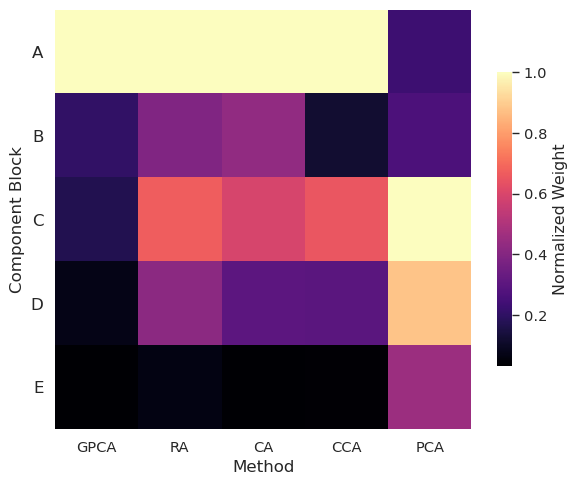

In [6]:
weights_gpca = np.abs(gpca.vects_)[:, 0, None] / np.abs(gpca.vects_)[:, 0, None].max()
weights_ra   = np.abs(ra.lr.coef_) / np.abs(ra.lr.coef_.max())
weights_ca   = np.abs(ca.composites['PosNeg'].to_numpy())[:, None] / np.abs(ca.composites['PosNeg'].to_numpy()[:, None].max())
weights_cca  = np.abs(cca.cca.y_loadings_) / np.abs(cca.cca.y_loadings_.max())
weights_pc   = np.abs(pc.pca.components_.T) / np.abs(pc.pca.components_[0, :].max())

df_weights = pd.DataFrame(
    np.array([weights_gpca, weights_ra, weights_ca, weights_cca, weights_pc])[:, :, 0].T,
    columns=['GPCA', 'RA', 'CA', 'CCA', 'PCA']
)

sns.set_theme(context='paper', style='white', font='sans-serif', font_scale=1.2)
fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    df_weights, ax=ax, cmap='magma',
    cbar_kws={'shrink': 0.7, 'label': 'Normalized Weight'},
    linewidths=0.0, yticklabels=False
)

block_size = df_weights.shape[0] / 5
tick_positions = [block_size * (i + 0.5) for i in range(5)]
ax.set_yticks(tick_positions)
ax.set_yticklabels(['A', 'B', 'C', 'D', 'E'], rotation=0, fontsize=12)
ax.set_xlabel('Method', fontsize=12)
ax.set_ylabel('Component Block', fontsize=12)

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/weights_toy_model.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

## 2. Experiments Across m and N

In [ ]:
# --- Config ---
alpha   = 0.05
B       = 5
n_grid  = 10
N_min, N_max = 100, 1000
m_min, m_max = 5, 1000

# Added the u_values list here
u_values = [0.1, 0.2, 0.3, 0.5]

N_values = np.unique(np.logspace(np.log10(N_min), np.log10(N_max), n_grid).astype(int))
m_values = generate_m_values(n_points=n_grid, m_min=m_min, m_max=m_max)

os.makedirs('../figures/grid_experiments', exist_ok=True)

In [15]:
# --- Type I error (u = 0) remains the same ---
results_null = []
print("Running Type I Error experiments (u=0)...")
for N in tqdm(N_values):
    for m in m_values:
        for b in range(B):
            results_df, _ = run_experiment(N=N, m=m, d=20, u=0)
            for _, row in results_df.iterrows():
                results_null.append({'N': N, 'm': m, 'Method': row['Method'],
                                     'reject': row['p_value'] <= alpha, 'p_value': row['p_value']})

rejection_null = (
    pd.DataFrame(results_null)
    .groupby(['N', 'm', 'Method'])['reject']
    .mean().reset_index().rename(columns={'reject': 'rejection_rate'})
)
rejection_null.to_csv('../figures/grid_experiments/rejection_rates_null.csv', index=False)

Running Type I Error experiments (u=0)...


100%|██████████| 10/10 [01:37<00:00,  9.74s/it]


In [16]:
# --- Power (Iterating through u_values) ---
all_power_results = []

for u_val in u_values:
    results_power = []
    print(f"Running Power experiments for u = {u_val}...")
    
    for N in tqdm(N_values):
        for m in m_values:
            for b in range(B):
                results_df, _ = run_experiment(N=N, m=m, d=20, u=u_val)
                for _, row in results_df.iterrows():
                    results_power.append({
                        'u': u_val, # Track u in the data
                        'N': N, 
                        'm': m, 
                        'Method': row['Method'],
                        'reject': row['p_value'] <= alpha, 
                        'p_value': row['p_value']
                    })
    
    # Process results for this specific u
    rejection_power_u = (
        pd.DataFrame(results_power)
        .groupby(['u', 'N', 'm', 'Method'])['reject']
        .mean().reset_index().rename(columns={'reject': 'rejection_rate'})
    )
    
    # Save individual CSV for this u
    csv_name = f'rejection_rates_power_u_{str(u_val).replace(".", "p")}.csv'
    rejection_power_u.to_csv(f'../figures/grid_experiments/{csv_name}', index=False)
    
    # Append to a master list if you want to keep everything in memory
    all_power_results.append(rejection_power_u)

# Combine all power results into one DataFrame for easier plotting/analysis
rejection_power_all = pd.concat(all_power_results, ignore_index=True)


Running Power experiments for u = 0.1...


100%|██████████| 10/10 [02:15<00:00, 13.54s/it]


Running Power experiments for u = 0.2...


100%|██████████| 10/10 [02:05<00:00, 12.59s/it]


Running Power experiments for u = 0.3...


100%|██████████| 10/10 [02:12<00:00, 13.29s/it]


Running Power experiments for u = 0.5...


100%|██████████| 10/10 [02:03<00:00, 12.35s/it]


In [18]:

def plot_rejection_heatmaps(rejection_df, alpha, title, save_path):
    plt.rcParams.update({
        'text.usetex': False, 'font.family': 'serif',
        'font.size': 24, 'axes.titlesize': 26, 'axes.labelsize': 26,
        'xtick.labelsize': 24, 'ytick.labelsize': 24, 'axes.linewidth': 1.5
    })

    methods = sorted(rejection_df['Method'].unique())
    fig, axes = plt.subplots(1, len(methods), figsize=(6.5 * len(methods), 7.5), sharex=True, sharey=True)
    if len(methods) == 1:
        axes = [axes]

    cmap = plt.get_cmap('viridis')

    for ax, method in zip(axes, methods):
        df_m = rejection_df[rejection_df['Method'] == method]
        heatmap_data = df_m.pivot(index='m', columns='N', values='rejection_rate').sort_index()

        im = ax.imshow(heatmap_data.values, origin='lower', aspect='auto', cmap=cmap, vmin=0, vmax=1)
        ax.set_xticks(np.arange(len(heatmap_data.columns)))
        ax.set_xticklabels(heatmap_data.columns, rotation=45)
        ax.set_yticks(np.arange(len(heatmap_data.index)))
        ax.set_yticklabels(heatmap_data.index)
        ax.set_title(method, pad=15, fontweight='bold')
        ax.set_xlabel(r'Sample size $N$', labelpad=10)
        ax.set_ylabel(r'Dimensionality $m$', labelpad=10)
        ax.tick_params(axis='both', which='major', width=1.5, length=6)

    cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.08, pad=-0.3)
    cbar.set_label(r'Rejection rate ($\alpha = {}$)'.format(alpha), fontsize=24)
    cbar.ax.tick_params(labelsize=26, width=1.5, length=6)

    fig.suptitle(title, fontsize=28, y=1.02)
    plt.tight_layout()
    plt.savefig(save_path + '.png', dpi=400, bbox_inches='tight')
    plt.savefig(save_path + '.pdf', bbox_inches='tight')
    plt.show()

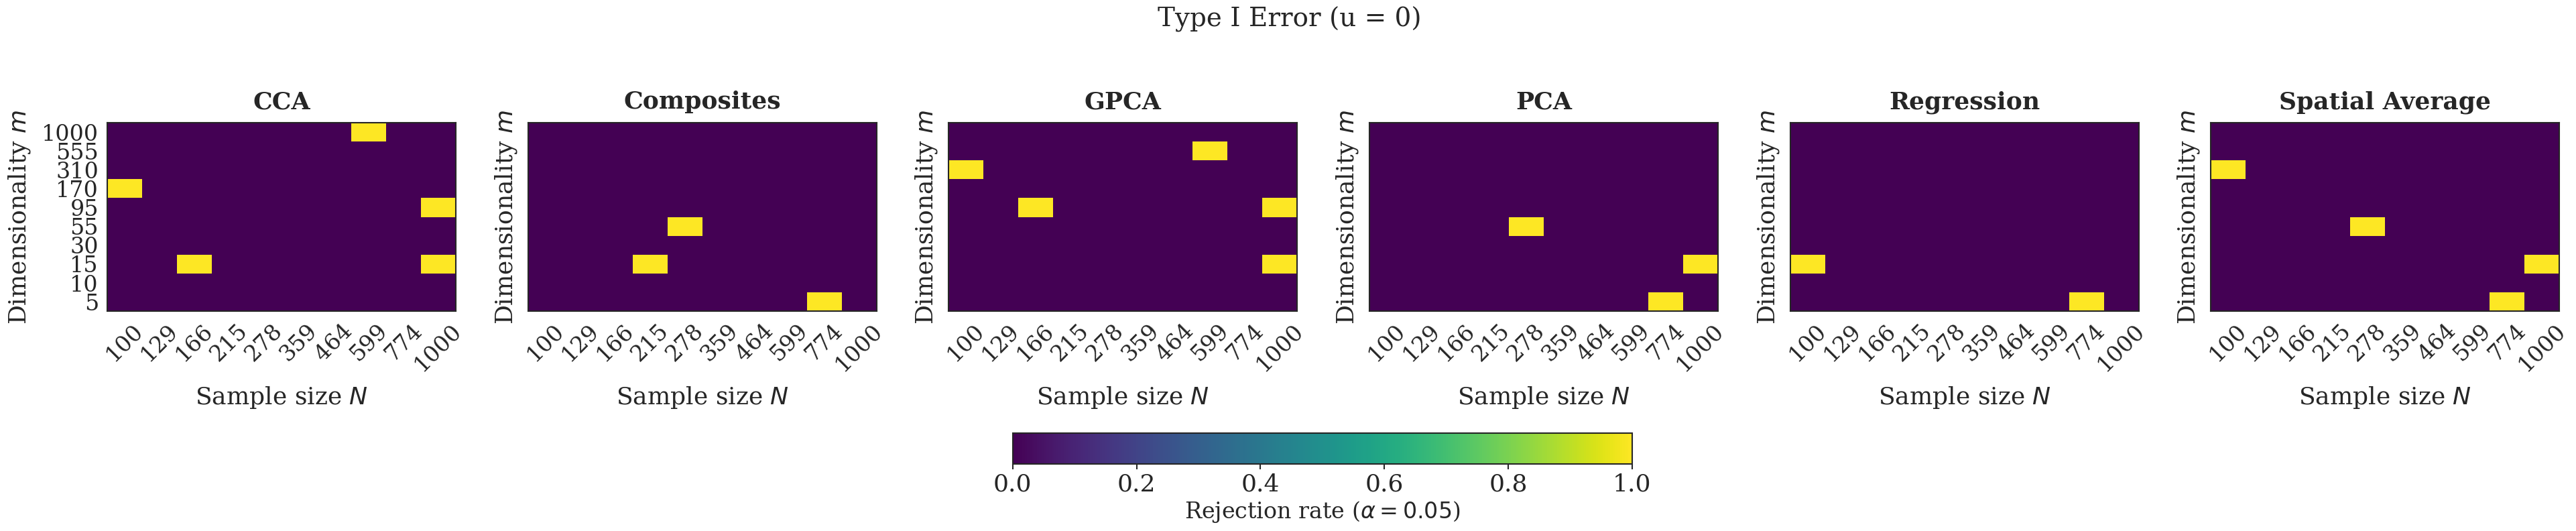

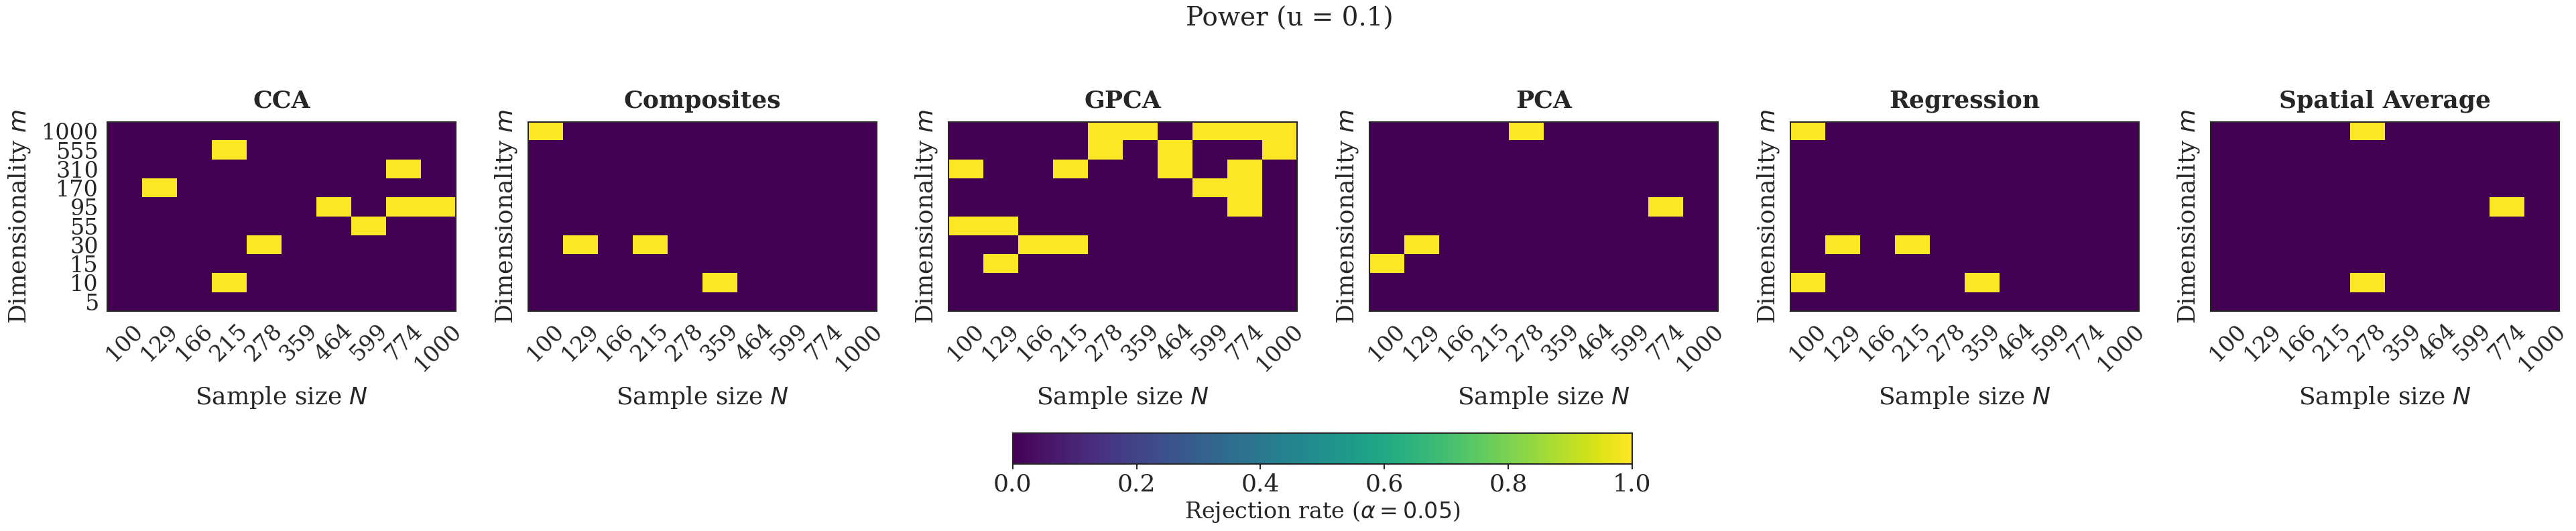

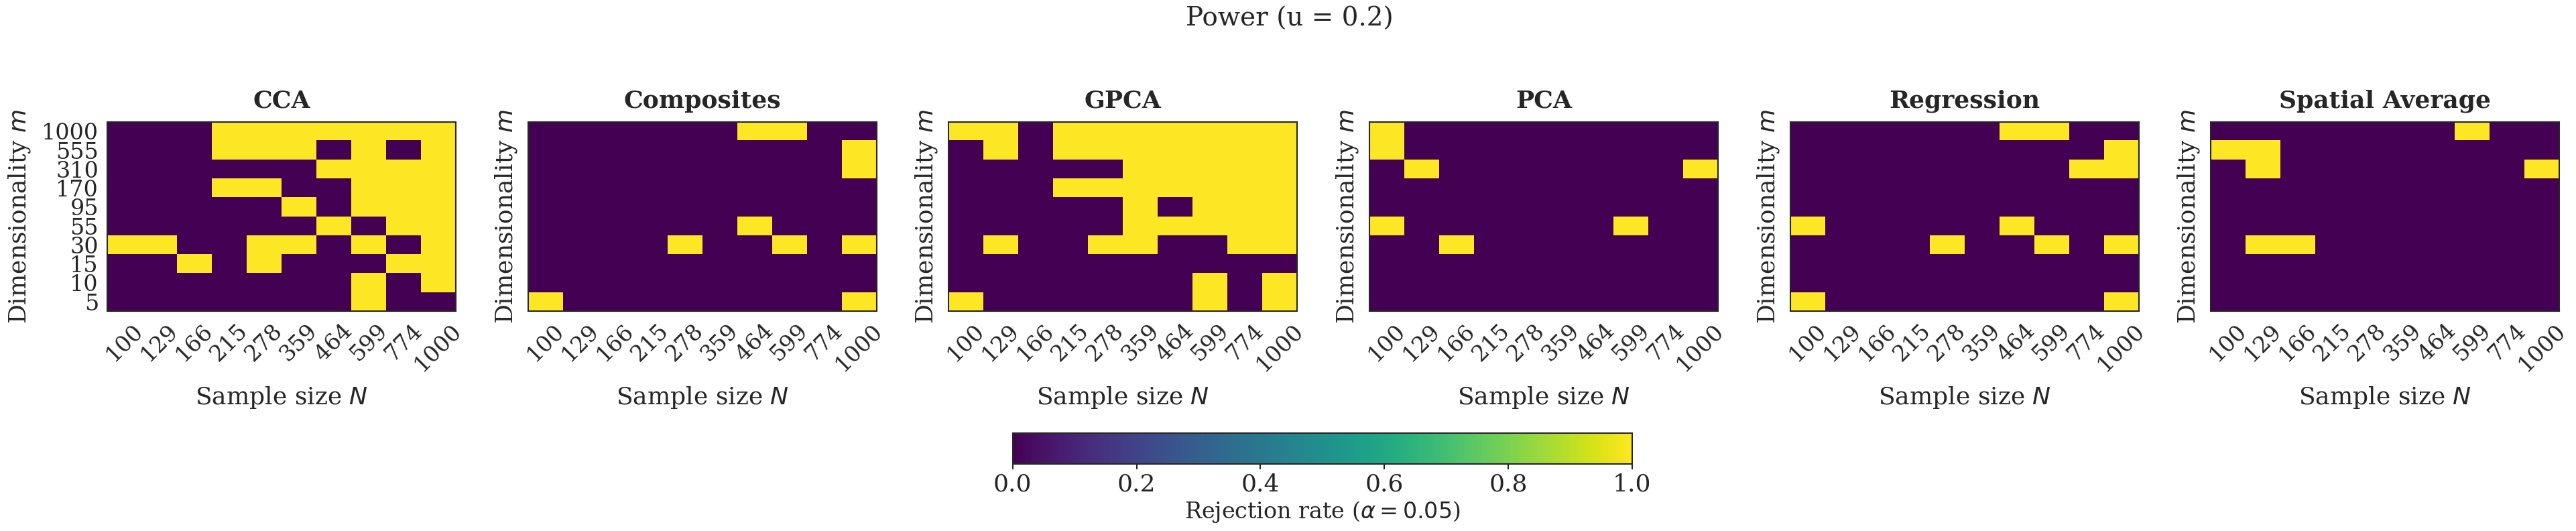

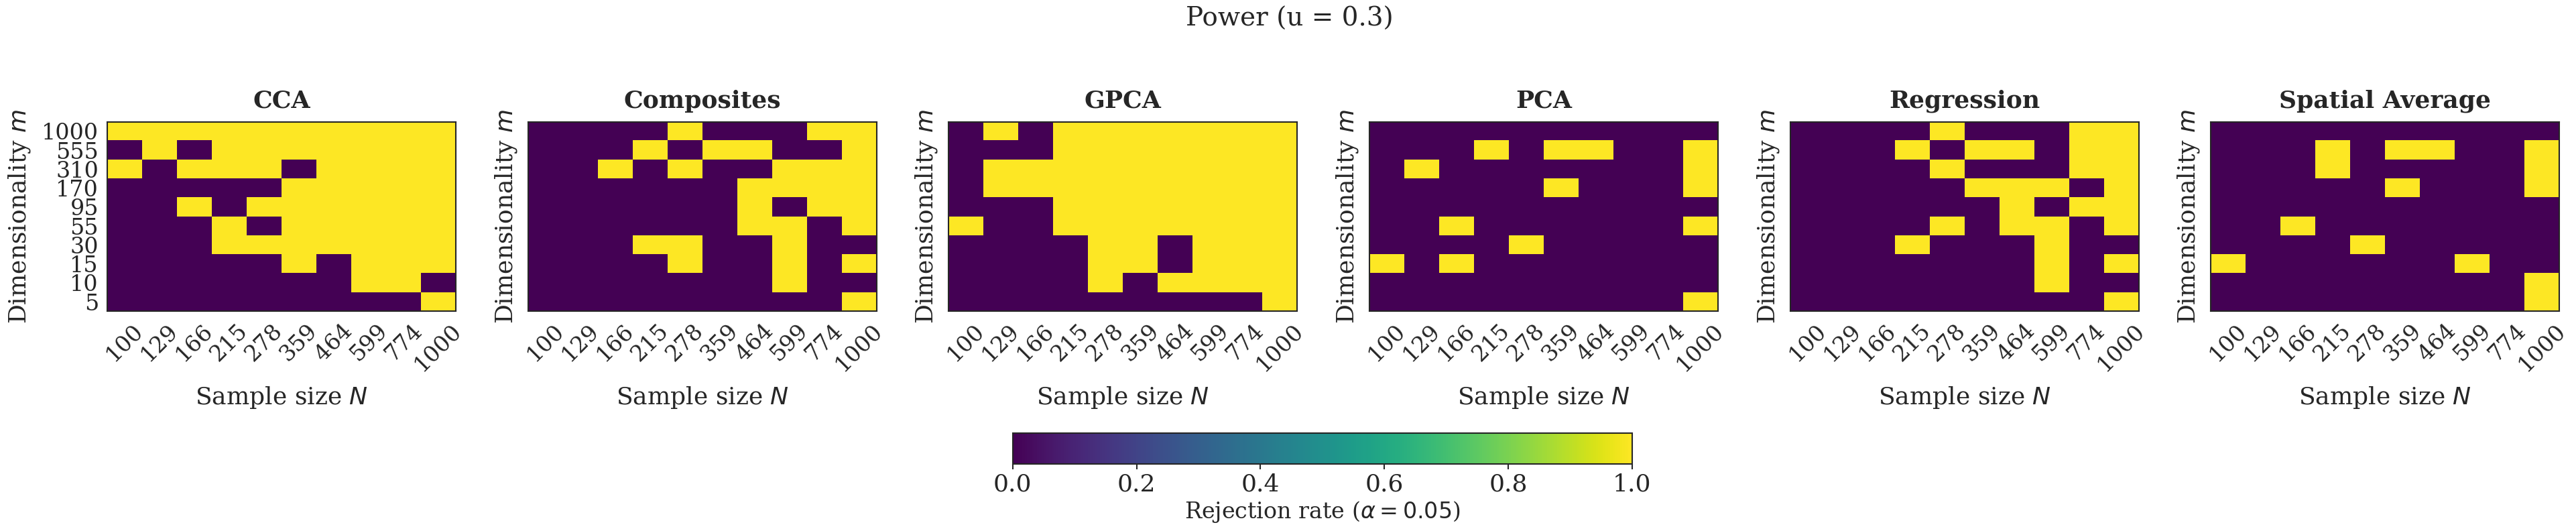

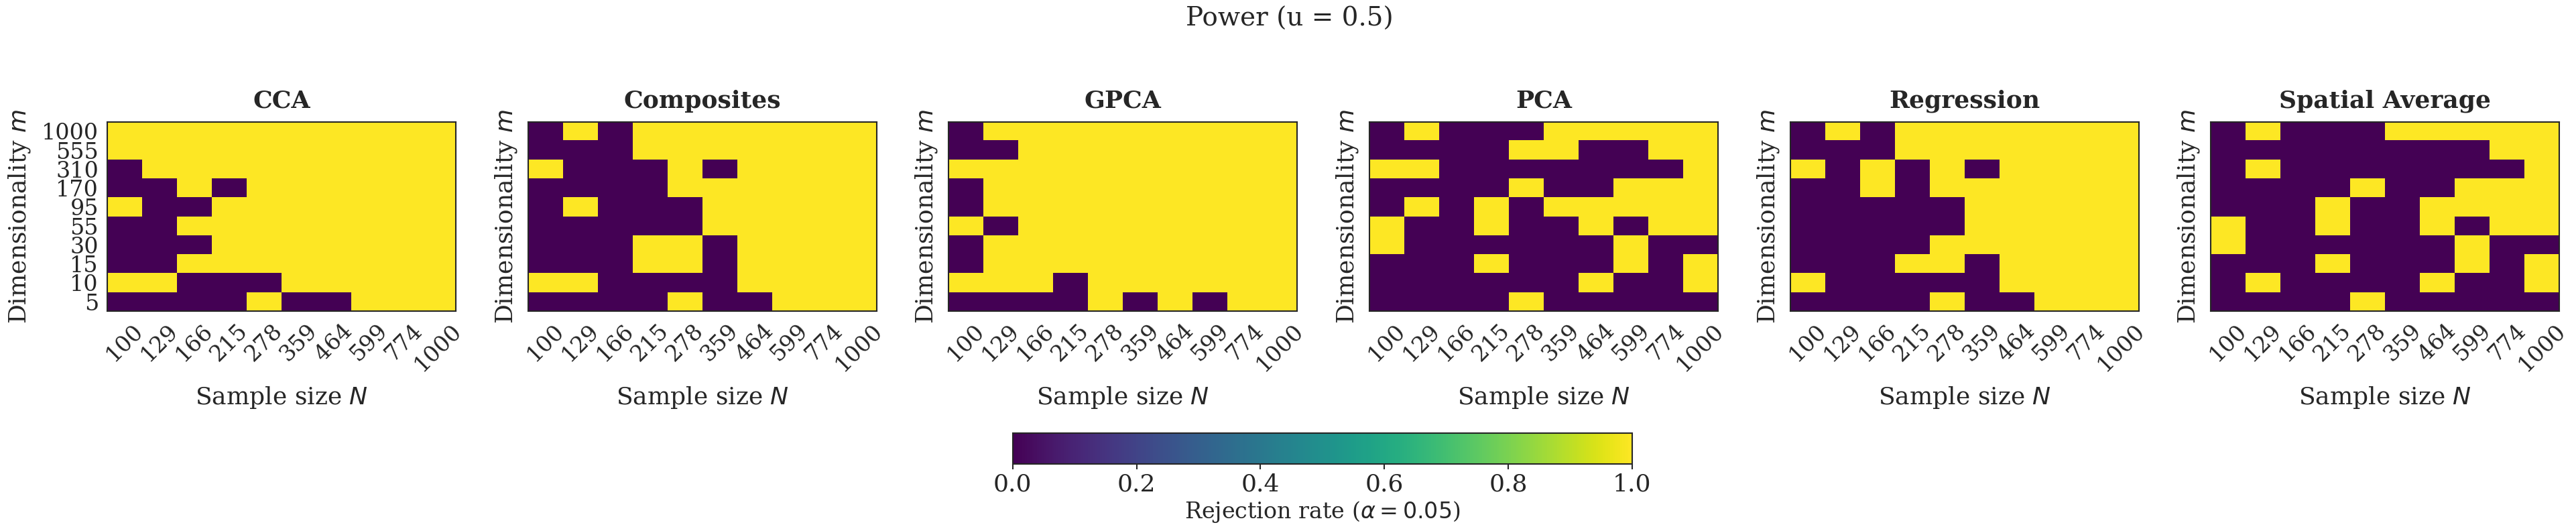

In [17]:
# --- Plotting ---

# Plot Null
plot_rejection_heatmaps(
    rejection_null, alpha,
    title='Type I Error (u = 0)',
    save_path='../figures/grid_experiments/rejection_heatmaps_null'
)

# Plot each u value in the power results
for u_val in u_values:
    subset = rejection_power_all[rejection_power_all['u'] == u_val]
    plot_rejection_heatmaps(
        subset, alpha,
        title=f'Power (u = {u_val})',
        save_path=f'../figures/grid_experiments/rejection_heatmaps_power_u_{str(u_val).replace(".", "p")}'
    )